# 2. Semantic Density Analysis

In this notebook, we analyze semantic density as a proxy for "wooden language" in political manifestos.

The objective is to distinguish between abstract and content-rich texts using a simple quantitative measure.

In [9]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter

In [10]:
from google.colab import files
uploaded = files.upload()

Saving legislatives (1).zip to legislatives (1) (2).zip


## 2.1 Loading the dataset

In [11]:
import os
import pandas as pd
import zipfile

# Assuming the uploaded zip file is 'legislatives (1) (1).zip'
zip_file_name = list(uploaded.keys())[0]

# Extract the contents of the zip file
with zipfile.ZipFile(zip_file_name, 'r') as zip_ref:
    zip_ref.extractall('/content/')

# Update the folder variable to point to the extracted directory
folder = "/content/text_files/1988/legislatives"

data = []

for filename in os.listdir(folder):
    if filename.endswith(".txt"):
        with open(os.path.join(folder, filename), "r", encoding="utf-8", errors="ignore") as f:
            text = f.read()
        data.append({"id": filename, "text": text})

df = pd.DataFrame(data)

print("Number of documents:", len(df))
df.head()

Number of documents: 3628


,id,text
0,EL176_L_1988_06_060_06_1_PF_01.txt,DEPARTEMENT DE L'OISE\n6ème CIRCONSCRIPTION\nC...
1,EL177_L_1988_06_095_07_1_PF_03.txt,LA FRANCE UNIE\nAVEC\nSciences Po / fonds CEVI...
2,EL175_L_1988_06_034_01_1_PF_04.txt,Sciences Po / fonds CEVIPOF\nELECTIONS LEGISLA...
3,EL177_L_1988_06_095_03_2_PF_01.txt,Sciences Po / fonds CEVIPOF\nElections législa...
4,EL176_L_1988_06_059_12_1_PF_03.txt,Sciences Po / fonds CEVIPOF\nELECTIONS LEGISLA...


## 2.2 Text cleaning

We normalize the text to reduce noise introduced by OCR and formatting.

In [12]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"\n+", " ", text)
    text = re.sub(r"[^a-zàâçéèêëîïôûùüÿñæœ\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_text"] = df["text"].apply(clean_text)

## 2.3 Semantic density definition

Semantic density is defined as the proportion of content words within a document.

This simplified version considers words longer than 3 characters as content words.

In [13]:
def semantic_density(text):
    words = text.split()
    content_words = [w for w in words if len(w) > 3]

    if len(words) == 0:
        return 0

    return len(content_words) / len(words)

df["density"] = df["clean_text"].apply(semantic_density)

## 2.4 Density distribution

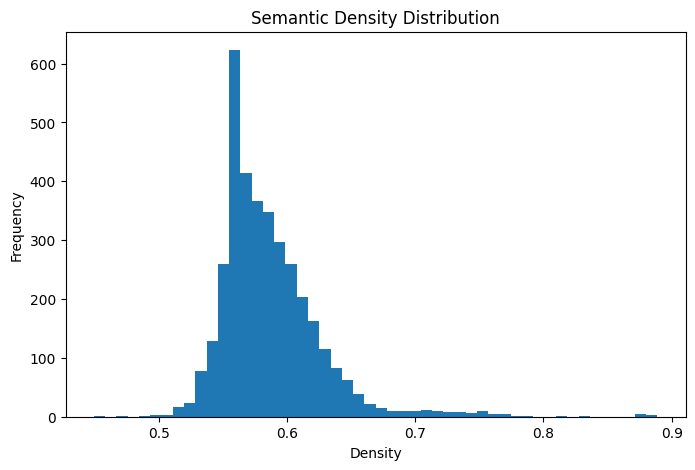

In [14]:
plt.figure(figsize=(8,5))
plt.hist(df["density"], bins=50)
plt.title("Semantic Density Distribution")
plt.xlabel("Density")
plt.ylabel("Frequency")
plt.show()

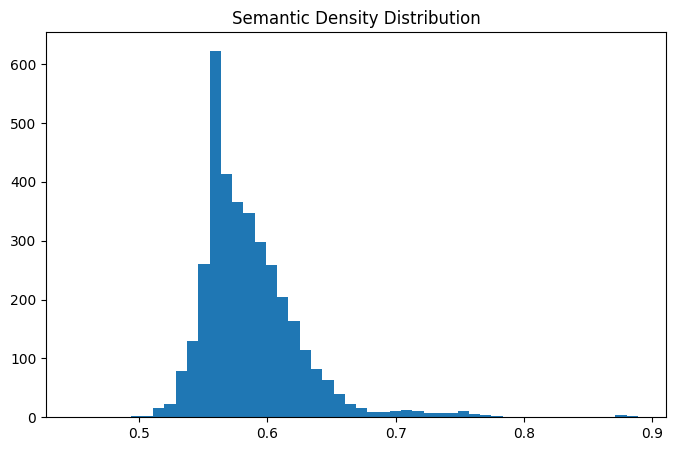

In [15]:
plt.figure(figsize=(8,5))
plt.hist(df["density"], bins=50)
plt.title("Semantic Density Distribution")
plt.savefig("density_plot.png", dpi=300, bbox_inches="tight")
plt.show()

## 2.5 Density statistics

In [16]:
df["density"].describe()

,density
count,3628.000000
mean,0.586725
std,0.039760
min,0.449393
25%,0.561003
50%,0.579079
75%,0.603977
max,0.888889


## 2.6 Quantile analysis

We analyze density distribution using quantiles to better identify extreme documents.

In [17]:
df["density"].quantile([0.1, 0.25, 0.5, 0.75, 0.9])

,density
0.10,0.550716
0.25,0.561003
0.50,0.579079
0.75,0.603977
0.90,0.630248


## 2.7 Low vs High density groups

We define low-density and high-density documents using quantile thresholds.

In [18]:
low_threshold = df["density"].quantile(0.1)
high_threshold = df["density"].quantile(0.9)

low_docs = df[df["density"] <= low_threshold]
high_docs = df[df["density"] >= high_threshold]

print("Low density docs:", len(low_docs))
print("High density docs:", len(high_docs))

Low density docs: 363
High density docs: 363


In [19]:
low_docs[["id", "density"]].head()

,id,density
2,EL175_L_1988_06_034_01_1_PF_04.txt,0.544194
14,EL174_L_1988_06_004_02_1_PF_02.txt,0.546485
16,EL177_L_1988_06_095_02_1_PF_05.txt,0.548807
17,EL176_L_1988_06_071_02_1_PF_02.txt,0.550593
18,EL177_L_1988_06_083_06_2_PF_01.txt,0.520095


In [20]:
high_docs[["id", "density"]].head()

,id,density
20,EL174_L_1988_06_021_04_2_BV_pdfmasterocr.txt,0.666667
23,EL174_L_1988_06_005_01_1_PF_04.txt,0.656805
28,EL176_L_1988_06_059_23_1_BV_pdfmasterocr.txt,0.751381
51,EL175_L_1988_06_049_03_1_PF_02.txt,0.634868
61,EL175_L_1988_06_037_02_2_PF_02.txt,0.673016


## 2.8 Qualitative comparison

In [21]:
print("LOW DENSITY TEXT:\n")
print(low_docs.iloc[0]["text"][:1000])

print("\n\nHIGH DENSITY TEXT:\n")
print(high_docs.iloc[0]["text"][:1000])

LOW DENSITY TEXT:

Sciences Po / fonds CEVIPOF
ELECTIONS LEGISLATIVES DE JUIN 1988, 1ère CIRCONSCRIPTION DE L'HERAULT
7 raisons de voter pour le candidat du Front National
Jean-Claude MARTINEZ
- Député de l'Hérault
- Né le 30 juillet 1945 à SETE
- Marié
- Une fille, 9 ans, Jeanne-Isabelle Occitane
- Agrégé de droit public et de Sciences po- litiques (Major de concours)
- Professeur à l'Université de Droit de Paris et à l'ENA du Maroc
- Rapporteur du budget de l'Education Na- tionale à la commission des finances
- Président de l'Association pour la sup- pression de l'impôt sur le revenu et la ré- forme fiscale (ASIREF).
Vu le Candidat
Si vous voulez un député
· qui soit présent à l'Assemblée nationale et qui remplisse effectivement le mandat pour lequel les contribuables le payent, comme les députés du Front National l'ont fait jusqu'ici, à la différence de leurs collègues des autres grou- pes presque toujours absents ;
· qui, une fois élu, ne s'entendra pas avec les socialistes contre 

## 2.9 Boxplot visualization

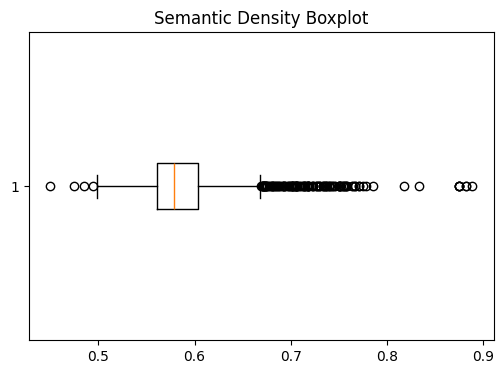

In [22]:
plt.figure(figsize=(6,4))
plt.boxplot(df["density"], vert=False)
plt.title("Semantic Density Boxplot")
plt.show()

## 2.10 Density vs document length

In [23]:
df["length"] = df["clean_text"].apply(lambda x: len(x.split()))

df[["density", "length"]].corr()

,density,length
density,1.000000,-0.420071
length,-0.420071,1.000000


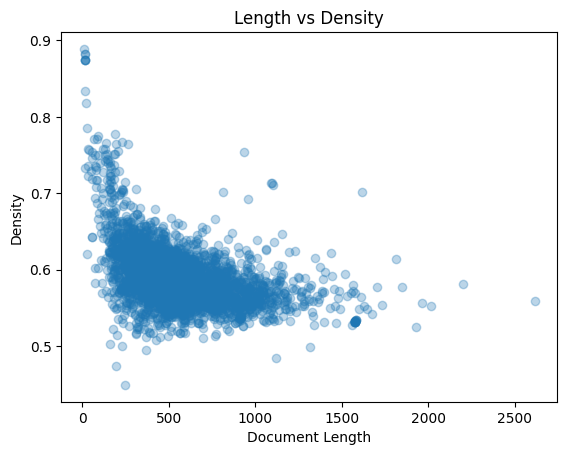

In [24]:
plt.scatter(df["length"], df["density"], alpha=0.3)
plt.xlabel("Document Length")
plt.ylabel("Density")
plt.title("Length vs Density")
plt.show()

## 2.11 Lexical analysis

In [25]:
low_words = " ".join(low_docs["clean_text"]).split()
high_words = " ".join(high_docs["clean_text"]).split()

print("Low density words:", Counter(low_words).most_common(10))
print("High density words:", Counter(high_words).most_common(10))

Low density words: [('de', 13995), ('la', 8666), ('et', 7368), ('l', 6188), ('le', 6119), ('à', 5356), ('les', 4881), ('des', 4439), ('d', 3674), ('pour', 3513)]
High density words: [('de', 5299), ('la', 3108), ('et', 2653), ('le', 2077), ('l', 1777), ('pour', 1769), ('du', 1679), ('à', 1480), ('les', 1420), ('des', 1300)]


## 2.12 Interpretation

The results show that semantic density varies across documents but remains within a relatively narrow range.

Low-density texts tend to include more generic and repetitive language, while high-density texts contain more specific terms such as names, institutions, and concrete references.

The relationship between document length and density appears weak, suggesting that density captures a distinct linguistic dimension.

Overall, semantic density provides a useful proxy for distinguishing between abstract and content-rich political discourse.